# **Name:Shivang Desai**

# **ID:202511034**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# **Task 1 — Data Preparation**

In [3]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Deep Learning"

csv_path = os.path.join(base_path, "data.csv")

df = pd.read_csv(csv_path)

df.head()

,Filename,AQI,PM2.5,PM10,O3,CO,SO2,NO2,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,32,13.0,32.0,31.0,219.0,10.0,20.0,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,37,19.0,37.0,18.0,272.0,11.0,21.0,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,37,19.0,37.0,18.0,272.0,11.0,21.0,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,43,22.0,40.0,36.0,268.0,16.0,7.0,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,47,24.0,46.0,19.0,216.0,8.0,14.0,a_Good


In [4]:
df = df[['Filename','AQI_Class']]

df.head()

,Filename,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good


In [5]:
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['AQI_Class'])

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['a_Good' 'b_Moderate' 'c_Unhealthy_for_Sensitive_Groups' 'd_Unhealthy'
 'e_Very_Unhealthy' 'f_Severe']
Number of classes: 6


In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4200
Validation: 900
Test: 900


In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [8]:
class AQIDataset(Dataset):

    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_name = self.dataframe.loc[idx, 'Filename']
        label = self.dataframe.loc[idx, 'label']

        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
image_dir = os.path.join(base_path, "sampled_images")

train_dataset = AQIDataset(train_df, image_dir, transform)
val_dataset = AQIDataset(val_df, image_dir, transform)
test_dataset = AQIDataset(test_df, image_dir, transform)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# **Task 2 – Basic CNN Model**

In [11]:
class BasicCNN(nn.Module):

    def __init__(self, num_classes):
        super(BasicCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BasicCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=6, bias=True)
  )
)


In [13]:
def train_model(model, train_loader, val_loader, epochs):

    train_losses = []
    val_losses = []

    train_acc = []
    val_acc = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = correct / total

        train_losses.append(running_loss / len(train_loader))
        train_acc.append(train_accuracy)


        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs,1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = correct / total

        val_losses.append(val_loss / len(val_loader))
        val_acc.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accuracy:.4f}")
        print(f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracy:.4f}")
        print()

    return train_losses, val_losses, train_acc, val_acc

In [15]:
epochs = 5

train_losses, val_losses, train_acc, val_acc = train_model(
    model,
    train_loader,
    val_loader,
    epochs
)

Epoch 1/5
Train Loss: 1.2825 | Train Acc: 0.4845
Val Loss: 1.0229 | Val Acc: 0.6089

Epoch 2/5
Train Loss: 0.9195 | Train Acc: 0.6457
Val Loss: 0.7449 | Val Acc: 0.7333

Epoch 3/5
Train Loss: 0.7076 | Train Acc: 0.7326
Val Loss: 0.6332 | Val Acc: 0.7411

Epoch 4/5
Train Loss: 0.5460 | Train Acc: 0.7931
Val Loss: 0.5912 | Val Acc: 0.7744

Epoch 5/5
Train Loss: 0.4355 | Train Acc: 0.8348
Val Loss: 0.5070 | Val Acc: 0.8311



# **Task 3 — Pretrained CNN (Transfer Learning)**

In [16]:
import torchvision.models as models

model_pretrained = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


In [17]:
freeze = 10

for i, param in enumerate(model_pretrained.parameters()):
    if i < freeze:
        param.requires_grad = False

In [18]:
num_features = model_pretrained.fc.in_features

model_pretrained.fc = nn.Linear(num_features, num_classes)

model_pretrained = model_pretrained.to(device)

In [19]:
criterion_pre = nn.CrossEntropyLoss()

optimizer_pre = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_pretrained.parameters()),
    lr=0.001
)

In [20]:
def train_pretrained(model, train_loader, val_loader, optimizer, epochs):

    train_losses = []
    val_losses = []

    train_acc = []
    val_acc = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion_pre(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = correct / total
        train_losses.append(running_loss / len(train_loader))
        train_acc.append(train_accuracy)

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion_pre(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs,1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = correct / total

        val_losses.append(val_loss / len(val_loader))
        val_acc.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accuracy:.4f}")
        print(f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accuracy:.4f}")
        print()

    return train_losses, val_losses, train_acc, val_acc

In [21]:
epochs = 5

train_losses_pre, val_losses_pre, train_acc_pre, val_acc_pre = train_pretrained(
    model_pretrained,
    train_loader,
    val_loader,
    optimizer_pre,
    epochs
)

Epoch 1/5
Train Loss: 1.1973 | Train Acc: 0.5298
Val Loss: 0.9576 | Val Acc: 0.6144

Epoch 2/5
Train Loss: 0.8131 | Train Acc: 0.6700
Val Loss: 1.1322 | Val Acc: 0.5989

Epoch 3/5
Train Loss: 0.6768 | Train Acc: 0.7350
Val Loss: 0.5213 | Val Acc: 0.8011

Epoch 4/5
Train Loss: 0.5033 | Train Acc: 0.8143
Val Loss: 0.4316 | Val Acc: 0.8233

Epoch 5/5
Train Loss: 0.4651 | Train Acc: 0.8250
Val Loss: 0.5080 | Val Acc: 0.8100



# **Task 4 – Model Training and Evaluation**

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [23]:
def evaluate_model(model, test_loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    cm = confusion_matrix(all_labels, all_preds)

    return acc, precision, recall, f1, cm, all_labels, all_preds

In [24]:
cnn_acc, cnn_prec, cnn_rec, cnn_f1, cnn_cm, y_true_cnn, y_pred_cnn = evaluate_model(
    model,
    test_loader
)

print("Basic CNN Performance")
print("Accuracy:", cnn_acc)
print("Precision:", cnn_prec)
print("Recall:", cnn_rec)
print("F1 Score:", cnn_f1)

Basic CNN Performance
Accuracy: 0.8155555555555556
Precision: 0.8224320954383642
Recall: 0.8155555555555556
F1 Score: 0.814150202602733


In [25]:
resnet_acc, resnet_prec, resnet_rec, resnet_f1, resnet_cm, y_true_res, y_pred_res = evaluate_model(
    model_pretrained,
    test_loader
)

print("Pretrained ResNet Performance")
print("Accuracy:", resnet_acc)
print("Precision:", resnet_prec)
print("Recall:", resnet_rec)
print("F1 Score:", resnet_f1)

Pretrained ResNet Performance
Accuracy: 0.8011111111111111
Precision: 0.8111288350687399
Recall: 0.8011111111111111
F1 Score: 0.8002594932172237


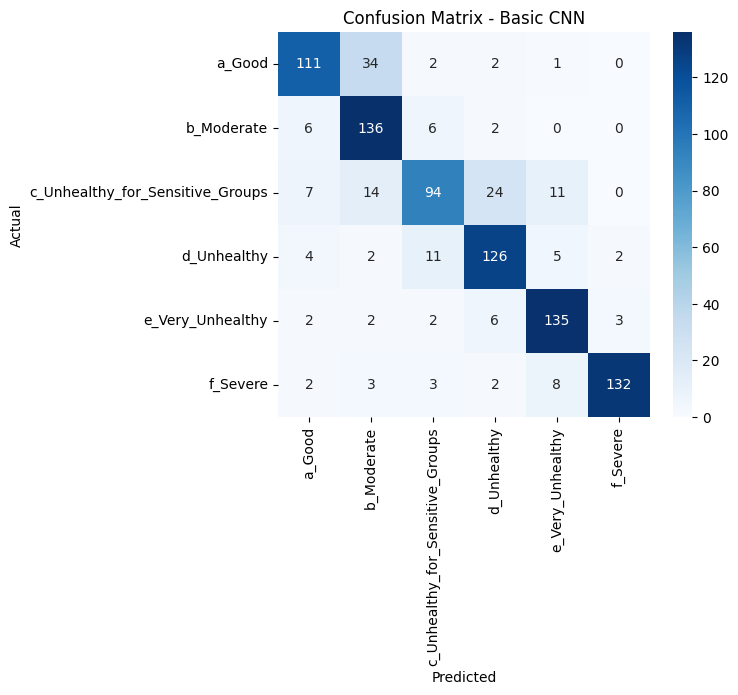

In [26]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Basic CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

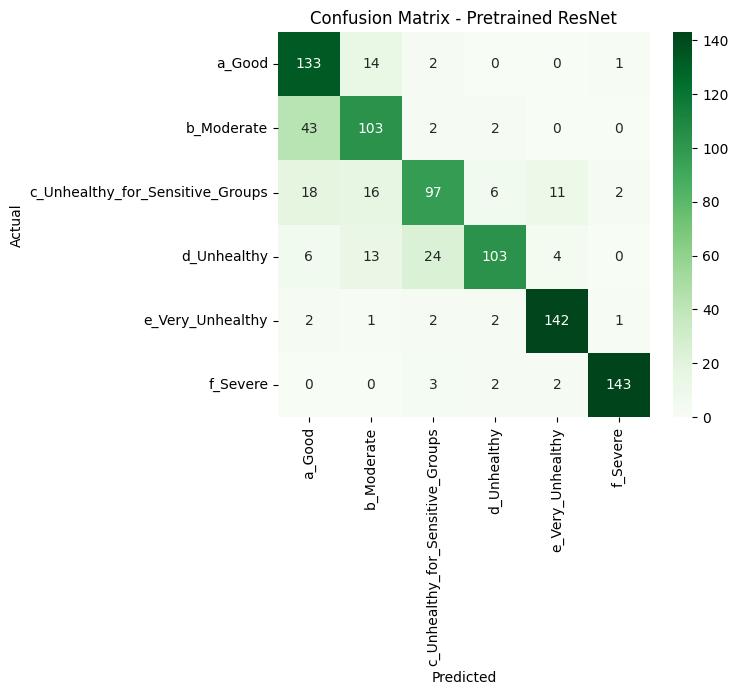

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Pretrained ResNet")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Task 5 – Training Curves**

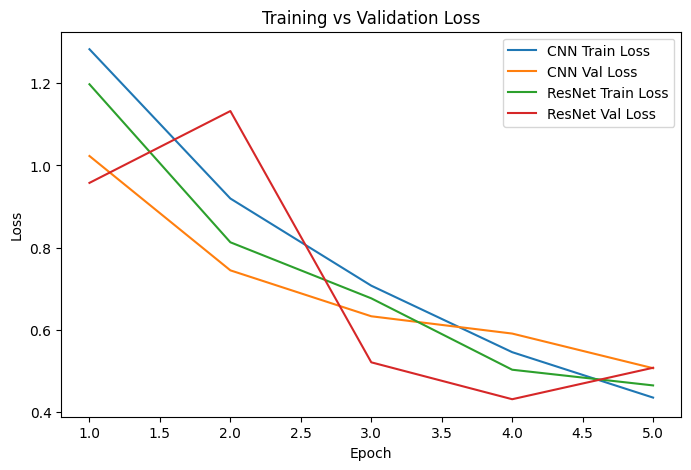

In [28]:
epochs_range = range(1, epochs+1)

plt.figure(figsize=(8,5))

plt.plot(epochs_range, train_losses, label='CNN Train Loss')
plt.plot(epochs_range, val_losses, label='CNN Val Loss')

plt.plot(epochs_range, train_losses_pre, label='ResNet Train Loss')
plt.plot(epochs_range, val_losses_pre, label='ResNet Val Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

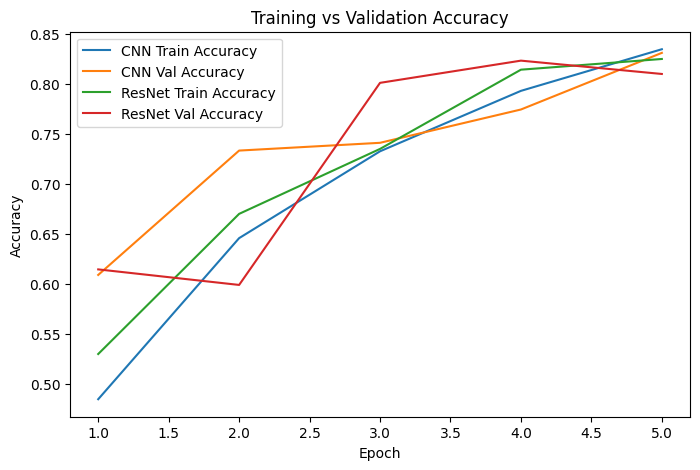

In [29]:
plt.figure(figsize=(8,5))

plt.plot(epochs_range, train_acc, label='CNN Train Accuracy')
plt.plot(epochs_range, val_acc, label='CNN Val Accuracy')

plt.plot(epochs_range, train_acc_pre, label='ResNet Train Accuracy')
plt.plot(epochs_range, val_acc_pre, label='ResNet Val Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# **Task 6 – Misclassification Analysis**

In [30]:
misclassified_indices = []

for i in range(len(y_true_res)):   # using pretrained model results
    if y_true_res[i] != y_pred_res[i]:
        misclassified_indices.append(i)

print("Total misclassified:", len(misclassified_indices))

Total misclassified: 179


In [31]:
import random

sample_misclassified = random.sample(misclassified_indices, min(10, len(misclassified_indices)))

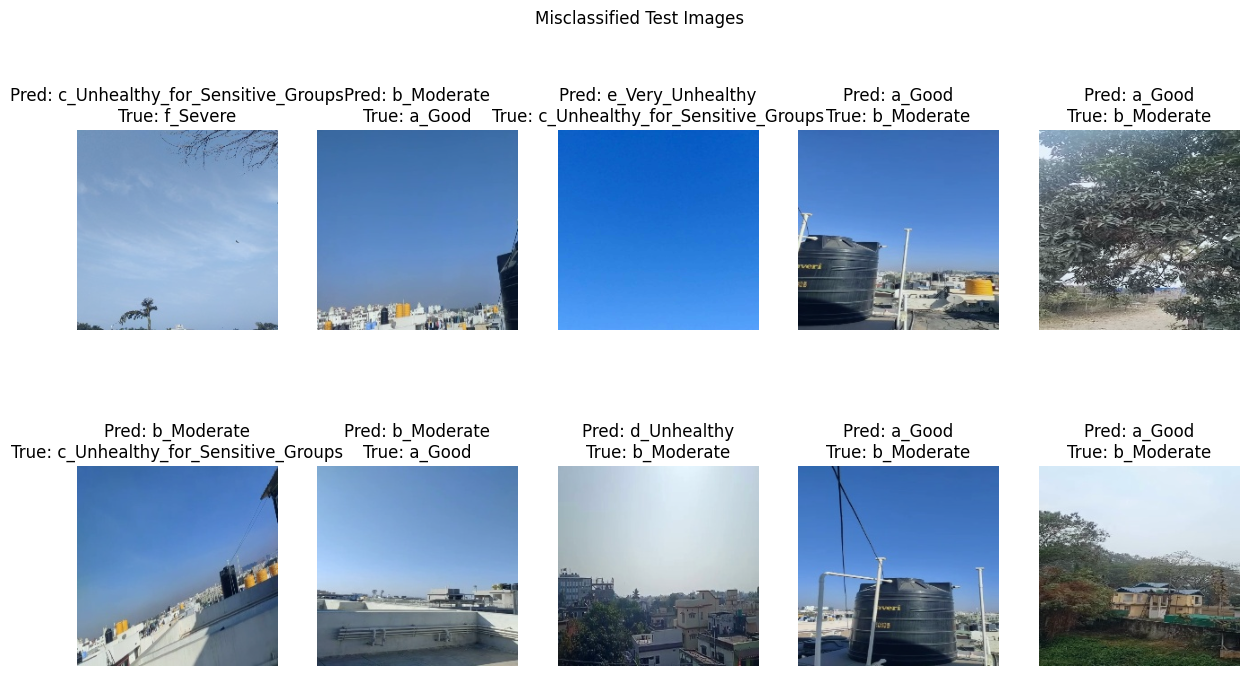

In [32]:
plt.figure(figsize=(15,8))

for i, idx in enumerate(sample_misclassified):

    image, label = test_dataset[idx]

    image = image.permute(1,2,0).numpy()

    image = (image - image.min()) / (image.max() - image.min())

    pred = y_pred_res[idx]
    true = y_true_res[idx]

    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.title(f"Pred: {label_encoder.inverse_transform([pred])[0]}\nTrue: {label_encoder.inverse_transform([true])[0]}")
    plt.axis("off")

plt.suptitle("Misclassified Test Images")
plt.show()